# Rossby Mode Equation function Testing  

**Purpose**: Code for testing the Rossby Mode equation functions on fake data

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook: 

In [1]:
%matplotlib inline


Import python libraries


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import cmocean.cm as cmo
import os

# Set path to access python functions
sys.path.append('/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/AirSeaCoupling/tools/')

#--- Luke's Python Functions ---# 
from ocean_analysis import moderossby

# Set plotting parameters 
fontsize = 16

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
plt.rcParams.update({
    "font.size": fontsize,                          # Fontsize
    "text.usetex": True,                           # Use LaTeX for all text
    "font.family": "serif",                         # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

Generate data for testing

In [3]:
# Set depth grid (0 to 1000 m)
zin = np.linspace(0, 1000, 51)   

#--------------------------------------------#
# Synthetic buoyancy frequency N(z) in rad/s
# Surface: ~5e-3 rad/s
# Pycnocline at 200–400 m: ~1e-2 rad/s
# Deep ocean: ~2e-3 rad/s
#--------------------------------------------#
# Set parameters
Nmax_depth = 100
Nmax_width = 50

# Compute buoyancy profile
nin = (5e-3
       + 7e-3 * np.exp(-(zin - Nmax_depth)**2 / (2 * Nmax_width**2))   # Pycnocline bump
       + 1e-3 * np.exp(-zin / 700))                                    # Weak deep stratification

# Pick a latitude
lat = 32  # degrees (SoCal, CCS region)

Plot Synthetic buoyancy frequency profile

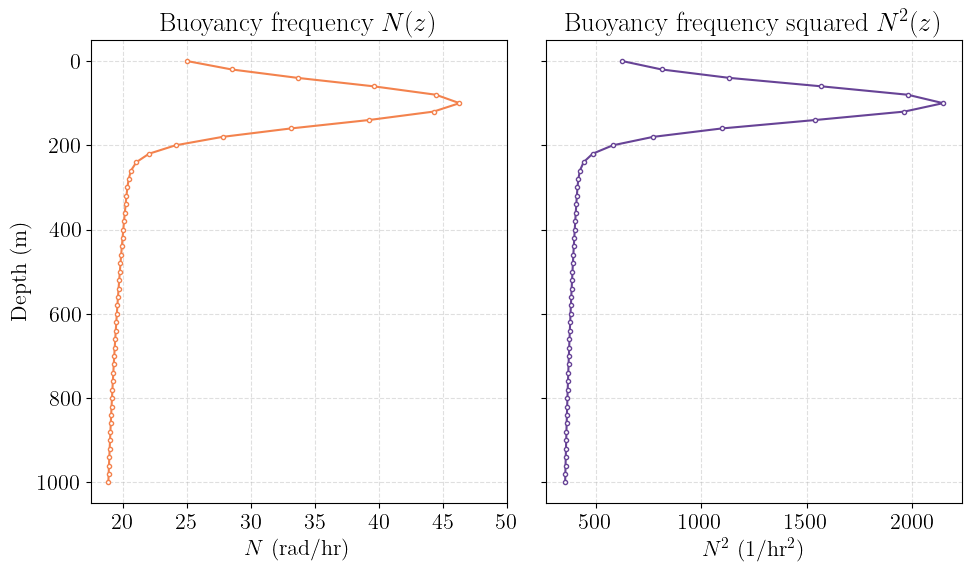

In [4]:
# Set parameters for plotting
N = nin*(60*60)      # buoyancy frequency [rad/hr]
N2 = N**2          # buoyancy frequency squared [hr^-2]

# Create figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

# Plot N
ax[0].plot(N, zin, '.-', lw=1.5, color=cmo.thermal(0.7), markersize=6, markerfacecolor='white')

# Set axis attributes
ax[0].set_title("Buoyancy frequency $N(z)$")
ax[0].invert_yaxis()
ax[0].set_xlabel(r"$N$ (rad/hr)")
ax[0].set_ylabel("Depth (m)")
ax[0].set_xticks(np.arange(20,50+5,5))
ax[0].set_xticks(np.arange(20,50+5,5))
ax[0].grid(True, ls='--', alpha=0.4)

# Plot N^2
ax[1].plot(N2, zin, '.-', lw=1.5, color=cmo.thermal(0.3), markersize=6, markerfacecolor='white')

# Set axis attributes
ax[1].set_title(r"Buoyancy frequency squared $N^2(z)$")
ax[1].set_xlabel(r"$N^2$ (1/hr$^{2}$)")
ax[1].grid(True, ls='--', alpha=0.4)

# Display figure
plt.tight_layout()
plt.show()

Run function

In [5]:
lambda1sq, w1, z1, lambda0sq, w0 = moderossby(zin, nin, lat, nmodes=10)

Plot the first few modes

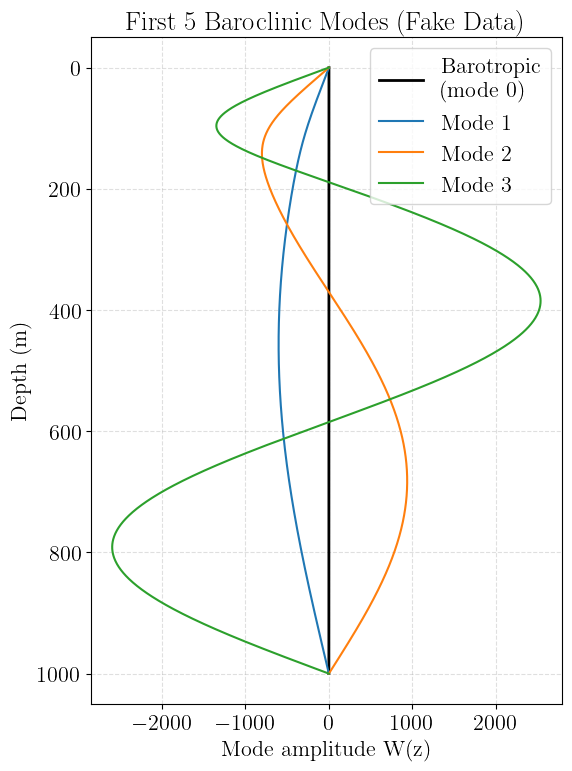

In [6]:
# Create figure and axes 
fig,ax = plt.subplots(figsize=(6, 8))

# Plot the Barotropic mode (mode 0)
ax.plot(w0, z1, 'k-', linewidth=2, label=f'Barotropic \n(mode 0)')

# Loop through first n modes
for j in range(3):

    # Plot each mode
    ax.plot(w1[:, j], z1, label=f"Mode {j+1}")

# Set figure attributes
ax.set_title("First 5 Baroclinic Modes (Fake Data)")
ax.set_xlabel("Mode amplitude W(z)")
ax.set_ylabel("Depth (m)")
ax.invert_yaxis()
ax.legend()
ax.grid(True, ls='--', alpha=0.4)

# Display figure
plt.tight_layout()
plt.show()


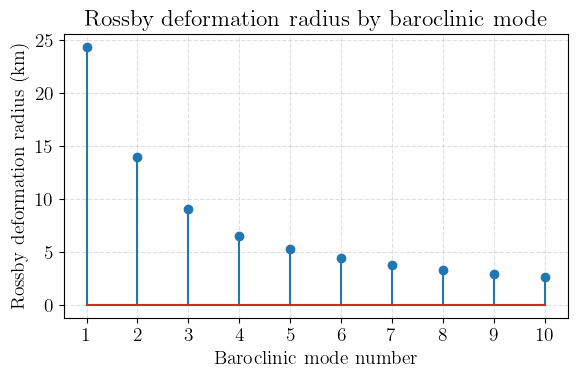

Mode  Rd (km)
  0  1285.90
  1    24.35
  2    13.99
  3     9.13
  4     6.58
  5     5.28
  6     4.43
  7     3.77
  8     3.30
  9     2.94
 10     2.64


In [13]:
#--------------------------------------------#
# Compute  Rossby deformation radius Rd for each mode
#--------------------------------------------#
# lambda1sq : array of λ² from moderossby
# Take absolute value in case of small numerical sign issues
lambda_abs = np.sqrt(np.abs(lambda1sq))  # |λ|, units 1/m (if your setup is dimensional)
Rd = 1.0 / lambda_abs                    # deformation radius [m]

# Set up mode numbers for plotting
mode_numbers = np.arange(1, len(Rd) + 1)

# Create figure 
fig, ax = plt.subplots(figsize=(6, 4))

# Plot Rd vs mode number
ax.stem(mode_numbers, Rd/1000)

# Set figure attributes
ax.set_title("Rossby deformation radius by baroclinic mode")
ax.set_xlabel("Baroclinic mode number")
ax.set_ylabel("Rossby deformation radius (km)")
ax.set_xticks(np.arange(1, len(Rd)+1))
ax.grid(True, ls='--', alpha=0.4)

# Display figure
plt.tight_layout()
plt.show()

# Combine barotropic + baroclinic eigenvalues
lambda_all_sq = np.concatenate(([lambda0sq], lambda1sq))
lambda_abs = np.sqrt(np.abs(lambda_all_sq))
Rd_all = 1.0 / lambda_abs   # [m]
mode_numbers_all = np.arange(0, len(Rd_all))  # 0 = barotropic

# Print Rd values
print("Mode  Rd (km)")
for m, rd in zip(mode_numbers_all, Rd_all):
    print(f"{m:3d}  {rd/1000:7.2f}")


Mode-1 Rossby radius Rd ≈ 24.3 km


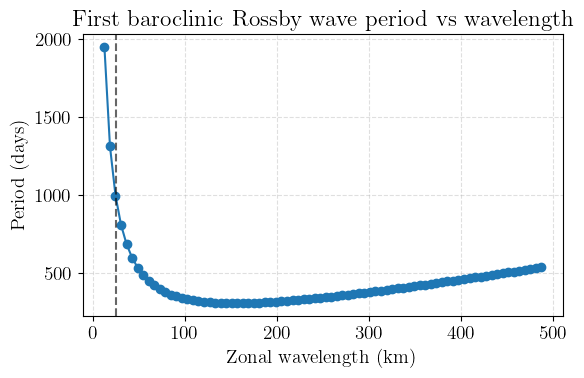

 Lx (km)   k (1e-6 m^-1)   period (days)
   12.2       516.133         1945.7
   42.2       148.812          599.9
   72.3        86.939          398.4
  102.3        61.407          332.9
  132.4        47.467          310.9
  162.4        38.685          308.3
  192.5        32.646          315.9
  222.5        28.237          329.6
  252.6        24.878          347.2
  282.6        22.233          367.5
  312.7        20.096          389.7
  342.7        18.334          413.4
  372.8        16.856          438.0
  402.8        15.598          463.6
  432.9        14.516          489.7
  462.9        13.573          516.4


In [14]:
#--------------------------------------------#
# Inputs you already have
#--------------------------------------------#
# lambda1sq : array of λ² from moderossby (baroclinic modes)
# lat       : latitude in degrees (same as used in moderossby)

lambda1sq_mode1 = lambda1sq[0]   # first baroclinic mode λ²
lambda1_mode1 = np.sqrt(np.abs(lambda1sq_mode1))
Rd_mode1 = 1.0 / lambda1_mode1        # [m]

print(f"Mode-1 Rossby radius Rd ≈ {Rd_mode1/1000:.1f} km")

#--------------------------------------------#
# Physical parameters for β-plane
#--------------------------------------------#
Omega = 7.2921e-5          # Earth's rotation rate [rad/s]
Re = 6.371e6               # Earth radius [m]

phi = np.deg2rad(lat)      # latitude in radians
f = 2 * Omega * np.sin(phi)
beta = 2 * Omega * np.cos(phi) / Re   # meridional gradient of Coriolis [1/(m·s)]

#--------------------------------------------#
# Define a range of realistic wavenumbers
# Here: purely zonal waves (l = 0), wavelengths 100–1000 km
#--------------------------------------------#
# Lx = np.linspace(100e3, 1000e3, 50)   # wavelengths [m]
# k = 2 * np.pi / Lx                    # zonal wavenumber [m^-1]
# l = 0.0                               # meridional wavenumber [m^-1]

Lx = np.linspace(0.5 * Rd_mode1, 20 * Rd_mode1, 80)  # [m]
k = 2 * np.pi / Lx                                   # [m^-1]
l = 0.0                                              # purely zonal

#--------------------------------------------#
# Rossby wave dispersion relation
# ω = -β k / (k^2 + l^2 + λ^2)
#--------------------------------------------#
lambda2 = lambda1sq_mode1            # λ² for mode 1 [m^-2]

omega = -beta * k / (k**2 + l**2 + lambda2)   # [rad/s]

# Period T = 2π / |ω|
T_sec = 2 * np.pi / np.abs(omega)    # [s]
T_days = T_sec / 86400.0             # [days]

#--------------------------------------------#
# Plot: period vs wavelength
#--------------------------------------------#
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(Lx / 1e3, T_days, 'o-')
ax.axvline(Rd_mode1/1000, color='k', linestyle='--', alpha=0.6,
           label=r"$R_d$")

ax.set_xlabel("Zonal wavelength (km)")
ax.set_ylabel("Period (days)")
ax.set_title("First baroclinic Rossby wave period vs wavelength")
ax.grid(True, ls='--', alpha=0.4)

plt.tight_layout()
plt.show()

#--------------------------------------------#
# Optional: print a few values
#--------------------------------------------#
print(" Lx (km)   k (1e-6 m^-1)   period (days)")
for L, kk, Td in zip(Lx[::5], k[::5], T_days[::5]):
    print(f"{L/1e3:7.1f}    {kk*1e6:10.3f}       {Td:8.1f}")


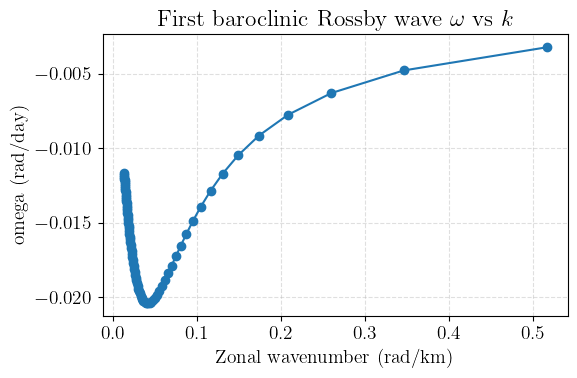

In [15]:
#--------------------------------------------#
# Plot: omega vs wavelength
#--------------------------------------------#
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(k*1000, omega*(60*60*24), 'o-')

ax.set_xlabel("Zonal wavenumber (rad/km)")
ax.set_ylabel("omega (rad/day)")
ax.set_title(r"First baroclinic Rossby wave $\omega$ vs $k$")
ax.grid(True, ls='--', alpha=0.4)

plt.tight_layout()
plt.show()

Barotropic Rd0 ≈ 1285.6 km
Mode-1   Rd1 ≈ 30.0 km


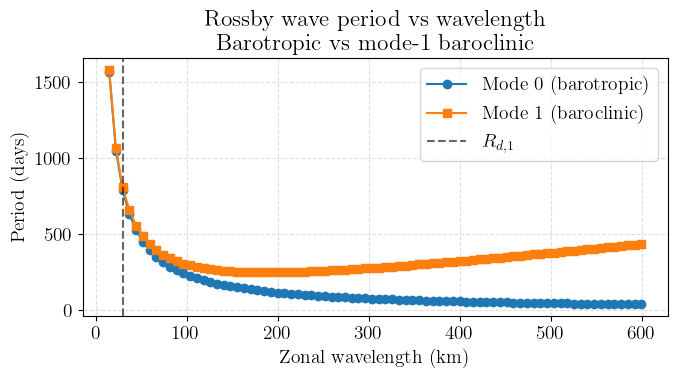


Sample values every ~10 points:
Lx (km)   T0 (days)   T1 (days)
   15.0      1569.9      1579.9
   89.0       264.5       323.5
  163.0       144.4       252.5
  237.0        99.4       256.5
  311.0        75.8       281.9
  385.1        61.3       316.5
  459.1        51.4       355.7
  533.1        44.3       397.6


In [46]:
#----------------------------------------------------#
# Inputs: from your moderossby output
#----------------------------------------------------#
# lambda0sq : scalar λ² for barotropic mode (mode 0)
# lambda1sq : array of λ² for baroclinic modes
# lat       : latitude in degrees

lambda1sq_mode1 = lambda1sq[0]       # mode-1 baroclinic λ²

#----------------------------------------------------#
# Compute deformation radii for mode 0 and mode 1
#----------------------------------------------------#
lambda0 = np.sqrt(np.abs(lambda0sq))
lambda1 = np.sqrt(np.abs(lambda1sq_mode1))

Rd0 = 1.0 / lambda0     # barotropic "Rossby radius" [m] (very large)
Rd1 = 1.0 / lambda1     # mode-1 Rossby radius [m]

print(f"Barotropic Rd0 ≈ {Rd0/1000:.1f} km")
print(f"Mode-1   Rd1 ≈ {Rd1/1000:.1f} km")

#----------------------------------------------------#
# β at your latitude
#----------------------------------------------------#
Omega = 7.2921e-5         # [rad/s]
Re = 6.371e6              # [m]

phi = np.deg2rad(lat)
beta = 2 * Omega * np.cos(phi) / Re   # [1/(m·s)]

#----------------------------------------------------#
# Wavelength range: scaled to mode-1 Rd
# (same Lx for both modes so you can compare directly)
#----------------------------------------------------#
Lx = np.linspace(0.5 * Rd1, 20 * Rd1, 80)  # wavelengths [m]
k = 2 * np.pi / Lx                         # zonal wavenumber [m^-1]
l = 0.0                                    # purely zonal waves

#----------------------------------------------------#
# Dispersion: ω = -β k / (k² + l² + λ²)
#   - for mode 0 (barotropic)
#   - for mode 1 (first baroclinic)
#----------------------------------------------------#
lambda2_0 = lambda0sq
lambda2_1 = lambda1sq_mode1

omega0 = -beta * k / (k**2 + l**2 + lambda2_0)   # barotropic ω [rad/s]
omega1 = -beta * k / (k**2 + l**2 + lambda2_1)   # mode-1 ω [rad/s]

T0_days = 2 * np.pi / np.abs(omega0) / 86400.0   # barotropic period [days]
T1_days = 2 * np.pi / np.abs(omega1) / 86400.0   # baroclinic period [days]

#----------------------------------------------------#
# Plot: periods vs wavelength for both modes
#----------------------------------------------------#
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(Lx/1000, T0_days, 'o-', label='Mode 0 (barotropic)')
ax.plot(Lx/1000, T1_days, 's-', label='Mode 1 (baroclinic)')

ax.axvline(Rd1/1000, color='k', linestyle='--', alpha=0.6,
           label=r"$R_{d,1}$")

ax.set_xlabel("Zonal wavelength (km)")
ax.set_ylabel("Period (days)")
ax.set_title("Rossby wave period vs wavelength\nBarotropic vs mode-1 baroclinic")
ax.grid(True, ls='--', alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()

# Optional: print a few sample values
print("\nSample values every ~10 points:")
print("Lx (km)   T0 (days)   T1 (days)")
for L, T0, T1 in zip(Lx[::10], T0_days[::10], T1_days[::10]):
    print(f"{L/1000:7.1f}   {T0:9.1f}   {T1:9.1f}")


In [48]:
np.pi/4

0.7853981633974483

In [50]:
30*2*np.pi

188.49555921538757

In [71]:
((200*1000)/0.1)*(1/60)*(1/60)*(1/24)  # 100 km wavelength to rad/day omega

23.148148148148145

In [69]:
10*(1/100)

0.1